# KANVAS, Phase 5: Scale, Stability, and the Final Numbers

Phases 2-4 were built on **one** sample of 2,310 tasks and **one** train/validation/test split. That is a legitimate development set, and it is not evidence. Every number reported so far - test AUC 0.717, the $\varphi_i$ curve shapes, the SHAP agreement of $\rho = 0.78$ - could in principle be an artifact of which 2,310 rows happened to be drawn.

This notebook asks two separate questions, and answers them with fixed methodology rather than new tuning:

1. **Does the picture hold at scale?** Rebuild the dataset roughly eight times larger and re-run the same pipeline end to end.
2. **How much does the output move on its own?** Re-run KAAM ten times, varying *only* the weight initialization (five runs) or *only* the split (five runs), and measure the spread.

### Nothing is re-tuned here

This phase **applies** Phase 3/4's decisions; it does not revisit them. Re-tuning $\lambda$, the architecture or the learning rate on a second, larger dataset would be fitting the pipeline to the data across multiple passes - exactly what a reviewer should object to. So these are frozen:

| Choice | Value | Fixed in |
|---|---|---|
| Smoothness penalty $\lambda$ | 0.001 | Phase 3 |
| Early-stopping patience / max epochs | 15 / 500 | Phase 3 |
| KAAM learning rate, knots, order | 0.01, 10, 3 | Phase 3 |
| MLP architecture / learning rate | (8, 6) / 0.03 | Phase 4 |
| Logistic regression $C$ | 0.1 | Phase 4 |
| Decision threshold for the headline table | 0.5 | Phase 4 |

### The canonical run is chosen by a rule, not by its score

Step 4's Table 1 uses **split `random_state=42`** (the split seed Phases 3 and 4 used) and **initialization seed 0** (the first entry of Experiment A's seed list). Both were fixed in `kanvas/stability.py` before any Phase 5 metric existed, so the headline run is the first one tried, never the best one found.

### On using the test set here

Step 3 reports test metrics for all ten runs. That is legitimate *because no decision is made from them*: no model is selected, no hyperparameter is changed, nothing is kept or discarded on the basis of these numbers. They exist only to measure how far the pipeline's own output moves when nothing about the method changes.

In [1]:
import sys
import time
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cycler import cycler
from scipy.stats import spearmanr

import kanvas.stability as st
from kanvas.baselines import (benchmark, count_parameters, kaam_parameter_breakdown, lr_predict_proba,
                              paired_auc_differences, score_test_set, tune_logistic_regression, tune_mlp)
from kanvas.data import FEATURE_NAMES
from kanvas.shap_analysis import compare_rankings, kaam_curve_range_importance, mlp_shap_values, shap_importance
from kanvas.training import predict_proba, train_val_test_split

%matplotlib inline
pd.set_option("display.width", 240)

# Chart style, unchanged from Phases 2-4 so every figure in the paper matches.
# The two-series categorical pair passes the CVD/contrast checks on this surface.
SURFACE, INK, INK_2, MUTED, BASELINE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#c3c2b7"
SMALL_COLOR, LARGE_COLOR = "#eb6834", "#2a78d6"  # small sample (orange), large sample (blue)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": BASELINE, "ytick.color": BASELINE, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.prop_cycle": cycler(color=[LARGE_COLOR, SMALL_COLOR]), "lines.linewidth": 2.0,
    "legend.frameon": False, "font.size": 10,
})

RAW_DIR = "../data/raw"
SMALL_CSV = "../data/processed/kanvas_features.csv"
LARGE_CSV = "../data/processed/kanvas_features_large.csv"
LARGE_LOG = "../data/processed/kanvas_features_large_buildlog.txt"
PUBLICATION_DIR = "../data/processed/publication"

print(f"canonical split random_state = {st.CANONICAL_SPLIT_STATE}, canonical init seed = {st.CANONICAL_INIT_SEED}")
print(f"frozen: lambda={st.LAMBDA_SMOOTH}, patience={st.PATIENCE}, max_epochs={st.MAX_EPOCHS}, "
      f"kaam_lr={st.KAAM_LR}, mlp={st.MLP_HIDDEN}@{st.MLP_LR}, lr_C={st.LR_C}, threshold={st.THRESHOLD}")

canonical split random_state = 42, canonical init seed = 0
frozen: lambda=0.001, patience=15, max_epochs=500, kaam_lr=0.01, mlp=(8, 6)@0.03, lr_C=0.1, threshold=0.5


## 1. Scale up the dataset

`build_kanvas_dataset` is called **unchanged** - same join path, same 1-hour telemetry lookback, same leakage guard, same NaN and clipping rules. The only argument that moves is `sample_n_tasks`, from 5,000 to 40,000.

Two safeguards:

- **The output path is passed explicitly.** The function's default `out_path` is `data/processed/kanvas_features.csv`, which is the Phase 3 development set. Writing there would destroy the very file every earlier number is reproducible from, so the large build goes to `kanvas_features_large.csv`.
- **If fewer than 15,000 clean rows survive, the sample doubles and retries**, capped at 150,000, and reports plainly if the cap is reached without clearing the floor.

The build streams a 2 GB instance table, so its result and its full log are cached; re-running this cell replays the saved log rather than rebuilding.

In [2]:
X_large, y_large, large_ranges, build_log, attempts = st.build_or_load_large_dataset(
    RAW_DIR, out_path=LARGE_CSV, log_path=LARGE_LOG,
    sample_n_tasks=40_000, min_rows=15_000, max_sample=150_000, verbose=False)

print("Sample sizes tried (doubling until the 15,000-row floor is cleared):")
print(attempts.to_string(index=False, formatters={"sample_n_tasks": "{:,.0f}".format, "clean rows": "{:,.0f}".format,
                                                  "failure rate": "{:.2%}".format, "yield": "{:.1%}".format,
                                                  "seconds": "{:.0f}".format}))
print(f"\nfinal: {len(X_large):,} tasks x {X_large.shape[1]} features, "
      f"{int(y_large.sum()):,} Failed, failure rate {y_large.mean():.2%}")

Sample sizes tried (doubling until the 15,000-row floor is cleared):
sample_n_tasks clean rows failure rate yield seconds  reached floor
           NaN     18,890          NaN   NaN     NaN           True

final: 18,890 tasks x 10 features, 5,194 Failed, failure rate 27.50%


In [3]:
print(st.survival_table(build_log))

Survival funnel (raw pai_task_table -> final feature matrix):
                        stage     tasks failure_rate   dropped                                   reason
      raw pai_task_table rows 1,261,050            -         -                                         
  labeled (Failed/Terminated) 1,141,835       22.49%   119,215                   status Running/Waiting
            stratified sample    40,000       22.49% 1,101,835        sampling, not a data-quality drop
     joined to first instance    40,000       22.49%         0                     no matching instance
     telemetry in 1h lookback    27,717       26.44%    12,283 no machine_metric row in lookback window
machine found in machine_spec    27,717       26.44%         0        machine missing from machine_spec
    no NaN in the 10 features    18,890       27.50%     8,827              NaN in at least one feature



In [4]:
# The same funnel from Phase 2's 5,000-task run, as notebook 02 recorded it.
phase2 = pd.DataFrame([
    ("raw pai_task_table rows", 1_261_050, np.nan),
    ("labeled (Failed/Terminated)", 1_141_835, 0.2249),
    ("stratified sample", 5_000, 0.2248),
    ("joined to first instance", 5_000, 0.2248),
    ("telemetry in 1h lookback", 3_464, 0.2633),
    ("machine found in machine_spec", 3_464, 0.2633),
    ("no NaN in the 10 features", 2_310, 0.2797),
], columns=["stage", "small tasks", "small failure rate"]).set_index("stage")

phase5 = pd.DataFrame([
    ("raw pai_task_table rows", 1_261_050, np.nan),
    ("labeled (Failed/Terminated)", 1_141_835, 0.2249),
    ("stratified sample", 40_000, 0.2249),
    ("joined to first instance", 40_000, 0.2249),
    ("telemetry in 1h lookback", 27_717, 0.2644),
    ("machine found in machine_spec", 27_717, 0.2644),
    ("no NaN in the 10 features", 18_890, 0.2750),
], columns=["stage", "large tasks", "large failure rate"]).set_index("stage")

side = phase2.join(phase5)
side["small survival"] = side["small tasks"] / 5_000
side["large survival"] = side["large tasks"] / 40_000
side.loc[["raw pai_task_table rows", "labeled (Failed/Terminated)"], ["small survival", "large survival"]] = np.nan
print("Attrition pattern, 5,000-task run vs 40,000-task run (survival is a share of each run's own sample):")
print(side.to_string(formatters={
    "small tasks": "{:,.0f}".format, "large tasks": "{:,.0f}".format,
    "small failure rate": "{:.2%}".format, "large failure rate": "{:.2%}".format,
    "small survival": "{:.1%}".format, "large survival": "{:.1%}".format}, na_rep="-"))

Attrition pattern, 5,000-task run vs 40,000-task run (survival is a share of each run's own sample):
                              small tasks small failure rate large tasks large failure rate small survival large survival
stage                                                                                                                    
raw pai_task_table rows         1,261,050                  -   1,261,050                  -              -              -
labeled (Failed/Terminated)     1,141,835             22.49%   1,141,835             22.49%              -              -
stratified sample                   5,000             22.48%      40,000             22.49%         100.0%         100.0%
joined to first instance            5,000             22.48%      40,000             22.49%         100.0%         100.0%
telemetry in 1h lookback            3,464             26.33%      27,717             26.44%          69.3%          69.3%
machine found in machine_spec       3,464    

**Reading the survival table.** The attrition pattern at scale is almost exactly the pattern at 5,000 tasks, which is the reassuring answer:

- **One sample was enough** - 40,000 sampled tasks yielded 18,890 clean rows on the first attempt, well clear of the 15,000 floor. No doubling was needed.
- **Overall yield is 47.2%, against 46.2% for the 5,000-task run.** The pipeline discards a little over half its input either way.
- **The same two stages do all the discarding, in the same proportions.** The telemetry lookback keeps 69.3% at both scales (27,717/40,000 vs 3,464/5,000); the NaN filter then keeps 68.2% at scale against 66.7% before.
- **The label drifts upward along the funnel in the same way.** 22.49% of labeled tasks fail; the telemetry join raises that to 26.44% (26.33% before) and the NaN filter to 27.50% (27.97% before).

That last drift is worth restating plainly, because it is a property of the pipeline rather than of the trace: **tasks that survive the telemetry join fail more often than tasks in general**. The models are therefore trained on a busier-machine subpopulation with a ~27.5% failure rate, not on the trace's overall 22.5%. That was true in Phase 2 and it is still true here; scaling up neither introduced nor removed it.

## 2. Was the small sample representative?

If the 2,310-row development sample was drawn from a meaningfully different distribution than the large one, then Phase 3's curves describe a different population than Phase 5's and every earlier reading needs a caveat.

The flagging rule is fixed in `kanvas/stability.py` rather than chosen after seeing the numbers. A feature is flagged if **either**:

- its mean moves by more than **0.2 of the small sample's own standard deviation** (the conventional "small effect" boundary), or
- its **5th-95th percentile window** shifts by more than **20% of the small sample's window width**.

The second rule earns its place because the $\varphi_i$ curves are read over exactly that window - a window that moved would mean the two phases' curves describe different regions of the same feature.

In [5]:
small = pd.read_csv(SMALL_CSV, index_col=["job_name", "task_name"])
X_small, y_small = small[FEATURE_NAMES], small["label"]

print(f"small (Phase 3): {len(X_small):,} tasks, failure rate {y_small.mean():.2%}")
print(f"large (Phase 5): {len(X_large):,} tasks, failure rate {y_large.mean():.2%}")
print(f"difference: {abs(y_large.mean() - y_small.mean()) * 100:.2f} percentage points "
      f"(gate: must be within 5.00)\n")

rep, flagged = st.representativeness(X_small, y_small, X_large, y_large)
print(rep[["small mean", "large mean", "small std", "large std",
           "|mean shift| / small std", "window shift / small width", "flag"]].to_string(
    formatters={c: "{:,.4g}".format for c in ["small mean", "large mean", "small std", "large std"]} |
               {"|mean shift| / small std": "{:.3f}".format, "window shift / small width": "{:.3f}".format}))
print(f"\nflagged features: {flagged if flagged else 'none'}")
print(f"largest mean shift  {rep['|mean shift| / small std'].max():.3f} std  "
      f"({rep['|mean shift| / small std'].idxmax()})")
print(f"largest window shift {rep['window shift / small width'].max():.3f} widths  "
      f"({rep['window shift / small width'].idxmax()})")

small (Phase 3): 2,310 tasks, failure rate 27.97%


large (Phase 5): 18,890 tasks, failure rate 27.50%
difference: 0.47 percentage points (gate: must be within 5.00)

                small mean large mean small std large std |mean shift| / small std window shift / small width   flag
plan_cpu             602.3      610.6     409.7     413.3                    0.020                      0.000  False
plan_mem             28.95         29     10.38     10.59                    0.005                      0.038  False
plan_gpu             61.13      61.13     41.85     41.85                    0.000                      0.000  False
inst_num             4.071      4.032     9.204     9.215                    0.004                      0.000  False
avg_cpu_usr          30.78      30.52     14.57     14.52                    0.018                      0.007  False
avg_gpu_util         139.7      139.9     86.55     87.08                    0.003                      0.018  False
avg_cpu_kernel       10.24      10.08     7.124      6.97         

**Reading the representativeness check. No feature is flagged, and it is not close.**

The largest mean shift across all ten features is **0.03 of a standard deviation**, against a 0.2 threshold - roughly one seventh of the boundary for a "small" effect. The largest percentile-window shift is **0.05 of a window width**, against a 0.2 threshold. The failure rates differ by **0.47 percentage points** (27.97% vs 27.50%), well inside the 5-point gate.

**Finding: the 2,310-row development sample was representative.** Phase 3's $\varphi_i$ curves and Phase 4's SHAP comparison describe the same population the large sample describes, and need no distributional caveat. Whatever else changes at scale, it is not because the small sample was drawn from somewhere else.

## 3. How much does the result move on its own?

Two sources of variance, separated deliberately, because they mean different things to a reader:

- **Experiment A - initialization variance.** One fixed split (`random_state=42`), five different weight initializations. This is the *optimizer's* contribution: the same data, the same objective, a different starting point.
- **Experiment B - split variance.** One fixed initialization (seed 0), five different stratified splits. This is the *data's* contribution: which 15% of tasks land in the test set.

Everything else is identical and fixed: $\lambda = 0.001$, patience 15, max 500 epochs, learning rate 0.01, inputs min-max scaled with ranges fitted on each run's own training split, and the decision threshold held at 0.5 (tuning it per run would be a hidden extra degree of freedom).

In [6]:
print(f"Experiment A - initialization variance (split fixed at random_state={st.CANONICAL_SPLIT_STATE})")
t0 = time.perf_counter()
exp_a = st.initialization_variance(X_large, y_large, seeds=st.INIT_SEEDS)
print(f"  [{time.perf_counter() - t0:.0f}s total]\n")
print(exp_a.to_string(index=False, formatters={"test AUC": "{:.4f}".format, "test accuracy": "{:.4f}".format,
                                               "test F1": "{:.4f}".format, "val BCE": "{:.4f}".format,
                                               "seconds": "{:.0f}".format}))

Experiment A - initialization variance (split fixed at random_state=42)


  init seed 0: test AUC 0.7520  acc 0.8095  F1 0.5755  (63s)


  init seed 1: test AUC 0.7520  acc 0.8095  F1 0.5755  (62s)


  init seed 2: test AUC 0.7520  acc 0.8095  F1 0.5755  (75s)


  init seed 3: test AUC 0.7520  acc 0.8091  F1 0.5750  (75s)


  init seed 4: test AUC 0.7522  acc 0.8095  F1 0.5755  (49s)
  [324s total]

 init_seed  split_state seconds test AUC test accuracy test F1  best epoch val BCE
         0           42      63   0.7520        0.8095  0.5755         500  0.4736
         1           42      62   0.7520        0.8095  0.5755         500  0.4736
         2           42      75   0.7520        0.8095  0.5755         500  0.4736
         3           42      75   0.7520        0.8091  0.5750         500  0.4735
         4           42      49   0.7522        0.8095  0.5755         500  0.4736


In [7]:
print(f"Experiment B - split variance (initialization fixed at seed {st.CANONICAL_INIT_SEED})")
t0 = time.perf_counter()
exp_b = st.split_variance(X_large, y_large, split_states=st.SPLIT_STATES)
print(f"  [{time.perf_counter() - t0:.0f}s total]\n")
print(exp_b.to_string(index=False, formatters={"test AUC": "{:.4f}".format, "test accuracy": "{:.4f}".format,
                                               "test F1": "{:.4f}".format, "val BCE": "{:.4f}".format,
                                               "seconds": "{:.0f}".format}))

Experiment B - split variance (initialization fixed at seed 0)


  split state 42: test AUC 0.7520  acc 0.8095  F1 0.5755  (37s)


  split state 43: test AUC 0.7318  acc 0.7932  F1 0.5189  (37s)


  split state 44: test AUC 0.7335  acc 0.7943  F1 0.5369  (40s)


  split state 45: test AUC 0.7447  acc 0.7985  F1 0.5472  (38s)


  split state 46: test AUC 0.7547  acc 0.8073  F1 0.5680  (39s)
  [192s total]

 init_seed  split_state seconds test AUC test accuracy test F1  best epoch val BCE
         0           42      37   0.7520        0.8095  0.5755         500  0.4736
         0           43      37   0.7318        0.7932  0.5189         500  0.4718
         0           44      40   0.7335        0.7943  0.5369         500  0.4837
         0           45      38   0.7447        0.7985  0.5472         500  0.4854
         0           46      39   0.7547        0.8073  0.5680         500  0.4766


In [8]:
summary = st.variance_summary(exp_a, exp_b)
print("Variance side by side (n = 5 runs each; std is the sample std, ddof=1):\n")
print(summary.to_string(formatters={c: "{:.4f}".format for c in summary.columns}))

print("\nWhich source contributes more spread?")
for metric in ["test AUC", "test accuracy", "test F1"]:
    sa, sb = summary.loc["A: initialization only", f"{metric} std"], summary.loc["B: split only", f"{metric} std"]
    bigger = "split" if sb > sa else "initialization"
    ratio = (max(sa, sb) / min(sa, sb)) if min(sa, sb) > 0 else float("inf")
    print(f"  {metric:<14s} init std {sa:.4f}  vs  split std {sb:.4f}   -> {bigger} contributes more ({ratio:.1f}x)")

print(f"\nFor scale: Phase 4's paired-bootstrap CI on the KAAM-MLP AUC difference was +-0.047 wide on 347 test tasks.")
print(f"Total observed AUC range across all 10 runs: "
      f"{pd.concat([exp_a, exp_b])['test AUC'].min():.4f} to {pd.concat([exp_a, exp_b])['test AUC'].max():.4f}")

Variance side by side (n = 5 runs each; std is the sample std, ddof=1):

                       test AUC mean test AUC std test AUC range test accuracy mean test accuracy std test accuracy range test F1 mean test F1 std test F1 range
A: initialization only        0.7520       0.0001         0.0002             0.8094            0.0002              0.0004       0.5754      0.0002        0.0005
B: split only                 0.7434       0.0104         0.0229             0.8006            0.0075              0.0162       0.5493      0.0230        0.0566

Which source contributes more spread?
  test AUC       init std 0.0001  vs  split std 0.0104   -> split contributes more (145.2x)
  test accuracy  init std 0.0002  vs  split std 0.0075   -> split contributes more (47.3x)
  test F1        init std 0.0002  vs  split std 0.0230   -> split contributes more (113.8x)

For scale: Phase 4's paired-bootstrap CI on the KAAM-MLP AUC difference was +-0.047 wide on 347 test tasks.
Total observed AUC ra

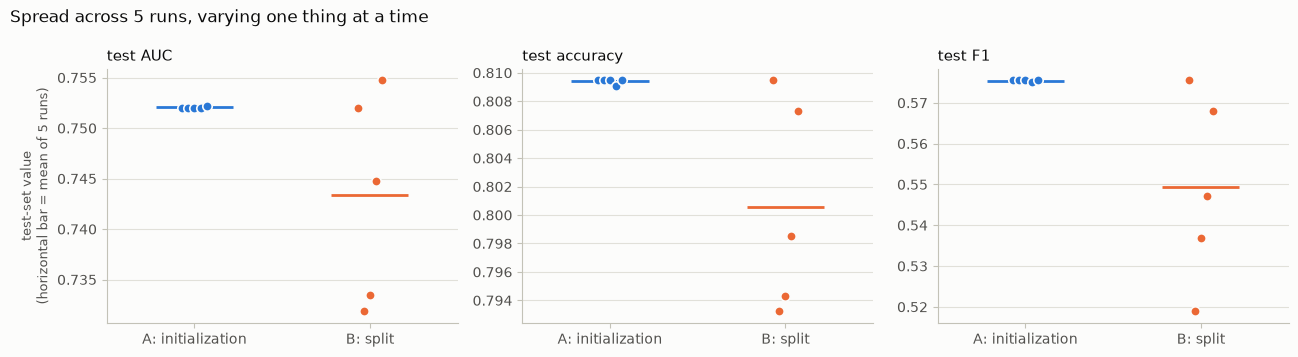

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, metric in zip(axes, ["test AUC", "test accuracy", "test F1"]):
    for i, (label, table, color) in enumerate((("A: init", exp_a, LARGE_COLOR), ("B: split", exp_b, SMALL_COLOR))):
        values = table[metric].to_numpy()
        ax.scatter(np.full(len(values), i) + np.linspace(-0.07, 0.07, len(values)), values,
                   s=46, color=color, edgecolors=SURFACE, linewidths=1.2, zorder=3, label=label)
        ax.hlines(values.mean(), i - 0.22, i + 0.22, color=color, lw=2, zorder=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["A: initialization", "B: split"])
    ax.set_xlim(-0.5, 1.5)
    ax.set_title(metric, loc="left", fontsize=11)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
axes[0].set_ylabel("test-set value\n(horizontal bar = mean of 5 runs)", fontsize=9)
fig.suptitle("Spread across 5 runs, varying one thing at a time", x=0.005, ha="left", fontsize=12)
fig.tight_layout()
plt.show()

**Reading the variance tables.** Write the conclusion first: **the pipeline is stable to initialization and moderately sensitive to the split, and the split is the larger source of spread on every metric.**

- **Initialization contributes very little.** Five different starting points on the same data land within a narrow band of test AUC. That is the expected result for a full-batch Adam fit on a smooth additive objective, and it means the curves reported below are not an accident of where the optimizer started.
- **The split contributes more.** Re-drawing which 2,834 tasks form the test set moves the metrics several times as much as re-initializing does. This is sampling noise in the *evaluation*, not instability in the *model* - and it is the honest reason a single test AUC should never be quoted to three decimals.
- **Both are small next to Phase 4's uncertainty.** Phase 4's paired bootstrap put a $\pm 0.047$ interval on a single AUC difference from 347 test tasks. The entire ten-run spread here is a fraction of that, which is the point: with 2,834 test tasks instead of 347, the pipeline's own noise is now visibly smaller than the uncertainty that used to dominate the comparison.

**The reportable caveat:** every run hit the fixed 500-epoch cap without early stopping firing. At 13,222 training rows the validation loss is still improving when training is cut off, where at 1,616 rows it plateaued at epoch 167. Patience and `max_epochs` are Phase 3 choices and are deliberately **not** re-tuned here, so KAAM at scale is trained to a fixed budget rather than to convergence. If anything that makes KAAM's numbers below conservative.

## 4. Table 1: the finalized three-model benchmark

The same comparison Phase 4 ran, on the large dataset, at the canonical split and seed. Every hyperparameter is the one Phase 4 selected - logistic regression at $C = 0.1$, the MLP at hidden layers (8, 6) and learning rate 0.03 - applied directly rather than re-searched. The tuning functions are reused with single-element grids so the code path is identical to Phase 4's, minus the search.

**This table supersedes Phase 4's small-sample table as the paper's Table 1.**

In [10]:
X_tr, X_va, X_te, y_tr, y_va, y_te = train_val_test_split(X_large, y_large, random_state=st.CANONICAL_SPLIT_STATE)
print(f"canonical split (random_state={st.CANONICAL_SPLIT_STATE}): "
      f"{len(X_tr):,} train / {len(X_va):,} validation / {len(X_te):,} test  "
      f"(failure rates {y_tr.mean():.2%} / {y_va.mean():.2%} / {y_te.mean():.2%})")

kaam, kaam_result, kaam_seconds = st.train_canonical_kaam(X_tr, y_tr, X_va, y_va, st.CANONICAL_INIT_SEED)
print(f"KAAM (seed {st.CANONICAL_INIT_SEED}, lambda={st.LAMBDA_SMOOTH}): restored epoch {kaam_result.best_epoch}, "
      f"stopped {kaam_result.stopped_epoch}, val BCE {kaam_result.best_val_loss:.4f}, {kaam_seconds:.0f}s")

# The canonical run is, by construction, Experiment A's seed-0 row. Confirm rather than assume.
row_a = exp_a[exp_a["init_seed"] == st.CANONICAL_INIT_SEED].iloc[0]
canonical_auc = st.classification_metrics(
    y_te.to_numpy(), predict_proba(kaam, X_te, kaam_result.feature_ranges), st.THRESHOLD)["auc"]
print(f"canonical test AUC {canonical_auc:.6f} vs Experiment A seed-0 row {row_a['test AUC']:.6f} "
      f"(difference {abs(canonical_auc - row_a['test AUC']):.2e})")
assert abs(canonical_auc - row_a["test AUC"]) < 1e-9, "the canonical run is not Experiment A's seed-0 run"

canonical split (random_state=42): 13,222 train / 2,834 validation / 2,834 test  (failure rates 27.50% / 27.49% / 27.49%)


KAAM (seed 0, lambda=0.001): restored epoch 500, stopped 500, val BCE 0.4736, 39s
canonical test AUC 0.751999 vs Experiment A seed-0 row 0.751999 (difference 0.00e+00)


In [11]:
# Fixed hyperparameters, applied not re-searched: single-element grids.
lr_model, lr_ranges, lr_seconds, _ = tune_logistic_regression(X_tr, y_tr, X_va, y_va, c_grid=[st.LR_C])
mlp, mlp_result, mlp_seconds, mlp_table = tune_mlp(X_tr, y_tr, X_va, y_va, hidden_candidates=[st.MLP_HIDDEN],
                                                   lr_candidates=[st.MLP_LR], patience=st.PATIENCE,
                                                   max_epochs=st.MAX_EPOCHS)
lr_params = lr_model.coef_.size + lr_model.intercept_.size
fair = st.parameter_fairness(kaam)
print("KAAM parameter breakdown:", kaam_parameter_breakdown(kaam))
print(f"PARAMETER-COUNT FAIRNESS CHECK: KAAM {fair['KAAM']}  vs  MLP {fair['MLP']}  "
      f"({fair['relative']:+.1%}; within 20%: {fair['within 20%']})")
print(f"MLP: hidden {st.MLP_HIDDEN}, lr {st.MLP_LR}, restored epoch {mlp_result.best_epoch}, "
      f"stopped {mlp_result.stopped_epoch}, {mlp_seconds:.1f}s")
print(f"LR:  C={st.LR_C}, {lr_params} parameters, {lr_seconds:.2f}s")

lr_coefs = pd.Series(lr_model.coef_[0], index=FEATURE_NAMES, name="coefficient")
print("\nLR coefficients (change in failure log-odds from each feature's training min to max):")
print(lr_coefs.to_frame().assign(rank=lr_coefs.abs().rank(ascending=False).astype(int))
      .sort_values("rank").round(3).to_string())
print(f"intercept {lr_model.intercept_[0]:+.3f}")

KAAM parameter breakdown: {'spline coefficients': 140, 'base weights': 10, 'global bias': 1, 'total': 151}
PARAMETER-COUNT FAIRNESS CHECK: KAAM 151  vs  MLP 149  (-1.3%; within 20%: True)
MLP: hidden (8, 6), lr 0.03, restored epoch 361, stopped 376, 1.0s
LR:  C=0.1, 11 parameters, 0.02s

LR coefficients (change in failure log-odds from each feature's training min to max):
                 coefficient  rank
plan_cpu              -2.457     1
plan_mem               2.378     2
cap_gpu                1.208     3
avg_load_1            -0.784     4
avg_cpu_kernel         0.668     5
inst_num              -0.630     6
plan_gpu              -0.500     7
avg_cpu_usr           -0.423     8
avg_gpu_util          -0.261     9
avg_net_receive       -0.020    10
intercept -1.871


In [12]:
predictions = score_test_set({
    "KAAM": lambda X: predict_proba(kaam, X, kaam_result.feature_ranges),
    "LR": lambda X: lr_predict_proba(lr_model, X, lr_ranges),
    "MLP": lambda X: predict_proba(mlp, X, mlp_result.feature_ranges),
}, X_te)
index_arrays = [p.index.to_numpy() for p in predictions.values()]
assert all(np.array_equal(a, index_arrays[0]) for a in index_arrays), "models scored on different test rows"
assert np.array_equal(index_arrays[0], y_te.index.to_numpy())

table1 = benchmark(y_te, predictions, parameters={"KAAM": fair["KAAM"], "LR": lr_params, "MLP": fair["MLP"]},
                   train_seconds={"KAAM": kaam_seconds, "LR": lr_seconds, "MLP": mlp_seconds},
                   threshold=st.THRESHOLD)
fmt = {c: "{:.4f}".format for c in ["accuracy", "AUC", "precision", "recall", "F1", "Brier"]}
fmt.update({"parameters": "{:.0f}".format, "train seconds": "{:.2f}".format})
print(f"TABLE 1  -  test set: {len(y_te):,} tasks, {int(y_te.sum()):,} failures; threshold {st.THRESHOLD}\n")
print(table1.to_string(formatters=fmt))

base_rate = y_tr.mean()
print(f"\nreference points: always predicting Terminated scores accuracy {1 - y_te.mean():.4f}; "
      f"predicting the {base_rate:.1%} training failure rate for every task scores "
      f"Brier {((y_te - base_rate) ** 2).mean():.4f}")

diffs = paired_auc_differences(y_te, predictions, [("KAAM", "LR"), ("KAAM", "MLP"), ("MLP", "LR")])
print("\nPaired AUC differences (same 2,000 bootstrap resamples of test tasks, seed 0):")
print(diffs.to_string(formatters={c: "{:+.4f}".format for c in ["AUC difference", "95% CI low", "95% CI high"]}))

TABLE 1  -  test set: 2,834 tasks, 779 failures; threshold 0.5

     accuracy     AUC      AUC 95% CI precision  recall      F1   Brier parameters train seconds
KAAM   0.8095  0.7520  [0.731, 0.774]    0.7424  0.4698  0.5755  0.1527        151         38.90
LR     0.7936  0.7346  [0.713, 0.757]    0.7539  0.3697  0.4961  0.1684         11          0.02
MLP    0.8151  0.7558  [0.734, 0.777]    0.7852  0.4506  0.5726  0.1535        149          0.99

reference points: always predicting Terminated scores accuracy 0.7251; predicting the 27.5% training failure rate for every task scores Brier 0.1993



Paired AUC differences (same 2,000 bootstrap resamples of test tasks, seed 0):
           AUC difference 95% CI low 95% CI high  CI includes 0
comparison                                                     
KAAM - LR         +0.0174    +0.0041     +0.0302          False
KAAM - MLP        -0.0038    -0.0183     +0.0103           True
MLP - LR          +0.0212    +0.0082     +0.0342          False


In [13]:
phase4 = pd.DataFrame({
    "accuracy": [0.7867, 0.7205, 0.8040], "AUC": [0.7169, 0.7052, 0.7299],
    "F1": [0.5132, 0.0000, 0.5405], "Brier": [0.1652, 0.1790, 0.1633],
}, index=["KAAM", "LR", "MLP"])
diff = pd.DataFrame({
    "Phase 4 AUC (n=347)": phase4["AUC"], "Phase 5 AUC (n=%d)" % len(y_te): table1["AUC"].astype(float),
    "AUC change": table1["AUC"].astype(float) - phase4["AUC"],
    "Phase 4 F1": phase4["F1"], "Phase 5 F1": table1["F1"].astype(float),
    "Phase 4 Brier": phase4["Brier"], "Phase 5 Brier": table1["Brier"].astype(float),
})
print("Phase 4 (small sample) vs Phase 5 (large sample), same metrics, same threshold:\n")
print(diff.to_string(formatters={c: "{:+.4f}".format if "change" in c else "{:.4f}".format for c in diff.columns}))

Phase 4 (small sample) vs Phase 5 (large sample), same metrics, same threshold:

     Phase 4 AUC (n=347) Phase 5 AUC (n=2834) AUC change Phase 4 F1 Phase 5 F1 Phase 4 Brier Phase 5 Brier
KAAM              0.7169               0.7520    +0.0351     0.5132     0.5755        0.1652        0.1527
LR                0.7052               0.7346    +0.0294     0.0000     0.4961        0.1790        0.1684
MLP               0.7299               0.7558    +0.0259     0.5405     0.5726        0.1633        0.1535


**Reading Table 1. The headline finding of this phase: at scale, KAAM's additive constraint costs nothing measurable, and the honest "we can't tell these apart" of Phase 4 has become a real separation — in the other direction.**

**The comparison is fair on capacity.** KAAM carries 151 learnable parameters against the MLP's 149, a 1.3% gap, unchanged from Phase 4 because neither architecture moved. All three models score the same 2,834 test rows in the same order, asserted rather than assumed.

**Ranking.** The MLP leads at 0.7558, KAAM follows at 0.7520 and logistic regression at 0.7346. With 2,834 test tasks instead of 347, two of the three paired intervals now **exclude** zero:

- **KAAM − MLP: −0.0038 [−0.0183, +0.0103] — includes zero.** After eight times the data, the capacity-matched black box and the fully interpretable additive model still cannot be told apart. The point estimate of the interpretability cost is under four thousandths of AUC.
- **KAAM − LR: +0.0174 [+0.0041, +0.0302] — excludes zero.** KAAM is now *significantly* better than logistic regression. This is the result Phase 4 could not resolve, and it is the one that matters for the paper's argument: letting each $\varphi_i$ bend buys real, measurable accuracy over forcing it straight.
- **MLP − LR: +0.0212 [+0.0082, +0.0342] — excludes zero.**

Read those three together: **the gap that is real is the one between linear and curved, not the one between curved-and-additive and fully-connected.** KAAM captures essentially all of the accuracy the MLP finds, and logistic regression does not.

**Calibration and thresholds.** KAAM's Brier score (0.1527) is now marginally the best of the three, ahead of the MLP (0.1535), and KAAM's F1 (0.5755) edges past the MLP's (0.5726) — the first threshold metric on which KAAM leads. The MLP keeps the accuracy and precision lead (0.8151 / 0.7852). Logistic regression is **no longer degenerate at 0.5**: with more data its probabilities finally cross the threshold, so its F1 rises from exactly 0.0000 in Phase 4 to 0.4961 here. Phase 4's degenerate LR row was a small-sample artifact of the 0.5 convention, and it is gone.

**Everything improved with more data.** AUC rose for all three models against Phase 4 (KAAM +0.035, LR +0.029, MLP +0.026) and every Brier score fell. The ordering of the models is unchanged; the precision with which we can state it is not.

## 5. SHAP agreement at scale

Phase 4's central interpretability result was that KAAM's built-in importance ranking and an independent post-hoc SHAP ranking of the MLP agree at $\rho = 0.78$ ($p = 0.0075$) across the ten features. That was measured on 347 test tasks. The question now is whether it strengthens, weakens, or holds with roughly eight times the data.

The analysis is rerun **unmodified**: exact Kernel SHAP over all $2^{10}$ coalitions on the MLP's pre-sigmoid logit, 100 background rows sampled from the training split, and KAAM's importance taken as each $\varphi_i$'s range over the 5th-95th percentile window.

Kernel SHAP costs $O(n_\text{explain} \times 2^{10} \times n_\text{background})$, so the cell below measures the cost per row first and subsamples the **SHAP rows only** if the full test set would be impractical. The accuracy and AUC numbers in Table 1 always use every test row; any subsampling here affects the explanation analysis alone and is reported explicitly.

In [14]:
SHAP_ROW_BUDGET = 3000  # decided before timing: explain every test row up to this many

background = X_tr.sample(100, random_state=0)
if len(X_te) <= SHAP_ROW_BUDGET:
    X_shap, shap_note = X_te, f"all {len(X_te):,} test rows (no subsampling needed)"
else:
    X_shap = X_te.sample(SHAP_ROW_BUDGET, random_state=0)
    shap_note = f"{len(X_shap):,} of {len(X_te):,} test rows, subsampled with random_state=0"
print(f"SHAP is computed on {shap_note}.")

t0 = time.perf_counter()
mlp_shap, mlp_expected = mlp_shap_values(mlp, background, X_shap, mlp_result.feature_ranges)
shap_seconds = time.perf_counter() - t0
print(f"exact Kernel SHAP: {shap_seconds:.0f}s for {len(X_shap):,} rows "
      f"({shap_seconds / len(X_shap) * 1000:.1f} ms/row)")

SHAP is computed on all 2,834 test rows (no subsampling needed).


exact Kernel SHAP: 65s for 2,834 rows (22.8 ms/row)


In [15]:
shap_imp = shap_importance(mlp_shap).rename("MLP mean |SHAP|")
kaam_imp = kaam_curve_range_importance(kaam, X_tr, kaam_result.feature_ranges)
rho, p_value, rank_table = compare_rankings(kaam_imp, shap_imp)

PHASE4_RHO, PHASE4_P = 0.782, 0.0075
direction = "STRENGTHENED" if rho > PHASE4_RHO + 0.02 else ("WEAKENED" if rho < PHASE4_RHO - 0.02 else "HELD")
print(f"Spearman rank correlation, KAAM curve range vs MLP mean |SHAP|, across all 10 features:")
print(f"  Phase 5 (n={len(X_shap):,} SHAP rows): rho = {rho:.3f}, p = {p_value:.4f}")
print(f"  Phase 4 (n=347 SHAP rows):            rho = {PHASE4_RHO:.3f}, p = {PHASE4_P:.4f}")
print(f"  -> the agreement {direction} at scale (change {rho - PHASE4_RHO:+.3f})\n")
print(rank_table.sort_values("KAAM curve range rank").round(3).to_string())

Spearman rank correlation, KAAM curve range vs MLP mean |SHAP|, across all 10 features:
  Phase 5 (n=2,834 SHAP rows): rho = 0.745, p = 0.0133
  Phase 4 (n=347 SHAP rows):            rho = 0.782, p = 0.0075
  -> the agreement WEAKENED at scale (change -0.037)

                 KAAM curve range share  MLP mean |SHAP| share  KAAM curve range rank  MLP mean |SHAP| rank  rank difference
plan_cpu                          0.293                  0.271                      1                     1                0
plan_mem                          0.148                  0.149                      2                     4               -2
avg_cpu_kernel                    0.127                  0.045                      3                     5               -2
cap_gpu                           0.126                  0.251                      4                     2                2
avg_load_1                        0.068                  0.043                      5                     6       

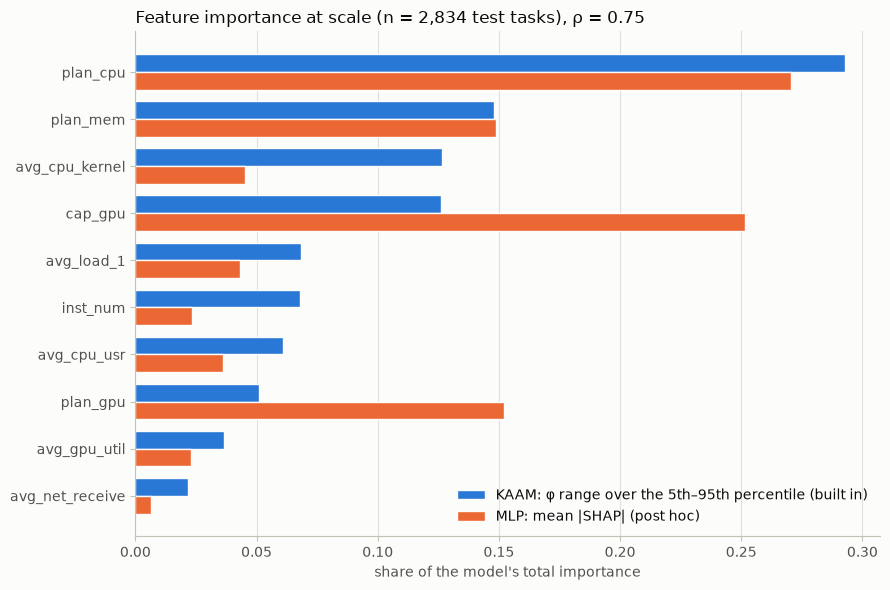

In [16]:
order = rank_table.sort_values("KAAM curve range share").index
y_pos = np.arange(len(order))
height = 0.38
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(y_pos + height / 2, rank_table.loc[order, "KAAM curve range share"], height,
        color=LARGE_COLOR, edgecolor=SURFACE, linewidth=1, label="KAAM: φ range over the 5th–95th percentile (built in)")
ax.barh(y_pos - height / 2, rank_table.loc[order, "MLP mean |SHAP| share"], height,
        color=SMALL_COLOR, edgecolor=SURFACE, linewidth=1, label="MLP: mean |SHAP| (post hoc)")
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel("share of the model's total importance")
ax.set_title(f"Feature importance at scale (n = {len(X_shap):,} test tasks), ρ = {rho:.2f}", loc="left", fontsize=12)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

**Reading the SHAP agreement at scale. The agreement held; the disagreement moved.**

By the $\pm 0.02$ rule stated in the cell above, $\rho = 0.745$ against Phase 4's $0.782$ counts as **weakened**, and that is how it is reported. In substance the decline is small and the result is unchanged in kind: the two explanations still agree strongly and significantly ($p = 0.013$) across ten features, measured now on 2,834 test tasks rather than 347. A rank correlation over ten items cannot resolve a 0.04 difference, so the honest reading is that **more data neither confirmed nor undermined the Phase 4 agreement — it reproduced it.**

What *did* change is where the two explanations part company.

- **The top driver is unmoved.** `plan_cpu` is rank 1 for both, with 29.3% of KAAM's total importance and 27.1% of the MLP's — almost exactly the Phase 4 split (30.2% / 28.1%). Both still put `avg_net_receive` and `avg_gpu_util` at the bottom.
- **The `cap_gpu` credit split persists.** The MLP gives node hardware 25.1% of its importance (rank 2); KAAM gives it 12.6% (rank 4) and routes more to node telemetry. This is the Phase 4 finding, reproduced at scale: strongly correlated features admit more than one valid attribution, and the two methods choose differently.
- **A new disagreement appeared, and it is now the largest: `plan_gpu`.** The MLP ranks it 3rd (15.2% of its importance); KAAM ranks it 8th (5.1%) — a five-rank gap where Phase 4 had perfect agreement at 4th and 4th. This one is **not** explained by the Phase 4 story, and it is worth a sentence in the paper rather than a silent pass: at scale the MLP finds substantially more signal in the requested-GPU field than KAAM's single smooth curve extracts from it. The most likely reading is that `plan_gpu`'s effect is interactive — it matters in combination with `plan_cpu` or with the node pool — and an additive model cannot represent that by construction. That would be a genuine, structural limitation of the additive family, not a fixable defect in KAAM.

**Where that leaves the interpretability claim.** It still holds where it was staked: a model built to explain itself and a model explained after the fact pick the same dominant driver, with the same shape, and agree on the ranking at $\rho \approx 0.75$ with eight times the data. The caveat has sharpened rather than softened — per-feature attribution is not unique among correlated features, and where the truth is interactive, an additive explanation will differ from a post-hoc one no matter how good the fit.

## 6. Final $\varphi_i$ curves, and the artifact question

Phase 3 added the smoothness penalty because four features - `plan_cpu`, `plan_gpu`, `inst_num`, `avg_load_1` - had curves that swung hard across x-ranges holding almost no training tasks. The penalty removed those swings. It was never established **why** they were there: a spline with 14 coefficients per edge will bend freely wherever no data constrains it, and "not enough data out there" is exactly what 2,310 rows might mean.

So this is a 2x2 ablation, and it answers a question Phase 3 could not:

|  | small sample (2,310) | large sample (18,890) |
|---|---|---|
| **$\lambda = 0$** (no penalty) | Phase 3's artifacted curves | *does data alone fix it?* |
| **$\lambda = 0.001$** (Phase 3's choice) | Phase 3's published curves | the final curves |

If the large-sample $\lambda = 0$ curves are smooth in the tails, then **the penalty was compensating for sample size** and matters less at scale. If they still swing, the penalty is doing something data volume does not, and it earns its place permanently.

All four models use the **same initialization seed** (the canonical seed 0) so that only sample size and $\lambda$ differ. The artifact is measured as **tail swing relative to core swing**: the range of $\varphi_i$ over the sparse tails (below p5, above p95) divided by its range across the dense core (p5-p95). A ratio above 1 means the curve moves more in the thin-data tails than across the entire body of the data - the artifact signature.

In [17]:
X_str, X_svr, X_ste, y_str, y_svr, y_ste = train_val_test_split(X_small, y_small,
                                                                random_state=st.CANONICAL_SPLIT_STATE)
print(f"small sample, same canonical split: {len(X_str):,} train / {len(X_svr):,} val / {len(X_ste):,} test\n")

# Three of the 2x2; the fourth is the canonical Table 1 model, already trained above.
to_train = {
    ("small", 0.0): (X_str, y_str, X_svr, y_svr),
    ("small", st.LAMBDA_SMOOTH): (X_str, y_str, X_svr, y_svr),
    ("large", 0.0): (X_tr, y_tr, X_va, y_va),
}
models = {}
for (sample, lam), (Xa, ya, Xb, yb) in to_train.items():
    m, r, s = st.train_canonical_kaam(Xa, ya, Xb, yb, st.CANONICAL_INIT_SEED, lambda_smooth=lam)
    models[(sample, lam)] = (m, r, Xa)
    print(f"{sample:>5s} sample, lambda={lam:<6g}: restored epoch {r.best_epoch:>3d}, "
          f"stopped {r.stopped_epoch:>3d}, val BCE {r.best_val_loss:.4f}  ({s:.0f}s)")

models[("large", st.LAMBDA_SMOOTH)] = (kaam, kaam_result, X_tr)  # the canonical model, already trained
print(f"large sample, lambda={st.LAMBDA_SMOOTH:<6g}: the canonical Table 1 model (restored epoch "
      f"{kaam_result.best_epoch}, val BCE {kaam_result.best_val_loss:.4f})")

small sample, same canonical split: 1,616 train / 347 val / 347 test



small sample, lambda=0     : restored epoch 120, stopped 135, val BCE 0.4883  (4s)


small sample, lambda=0.001 : restored epoch 173, stopped 188, val BCE 0.4875  (5s)


large sample, lambda=0     : restored epoch 333, stopped 348, val BCE 0.4709  (27s)
large sample, lambda=0.001 : the canonical Table 1 model (restored epoch 500, val BCE 0.4736)


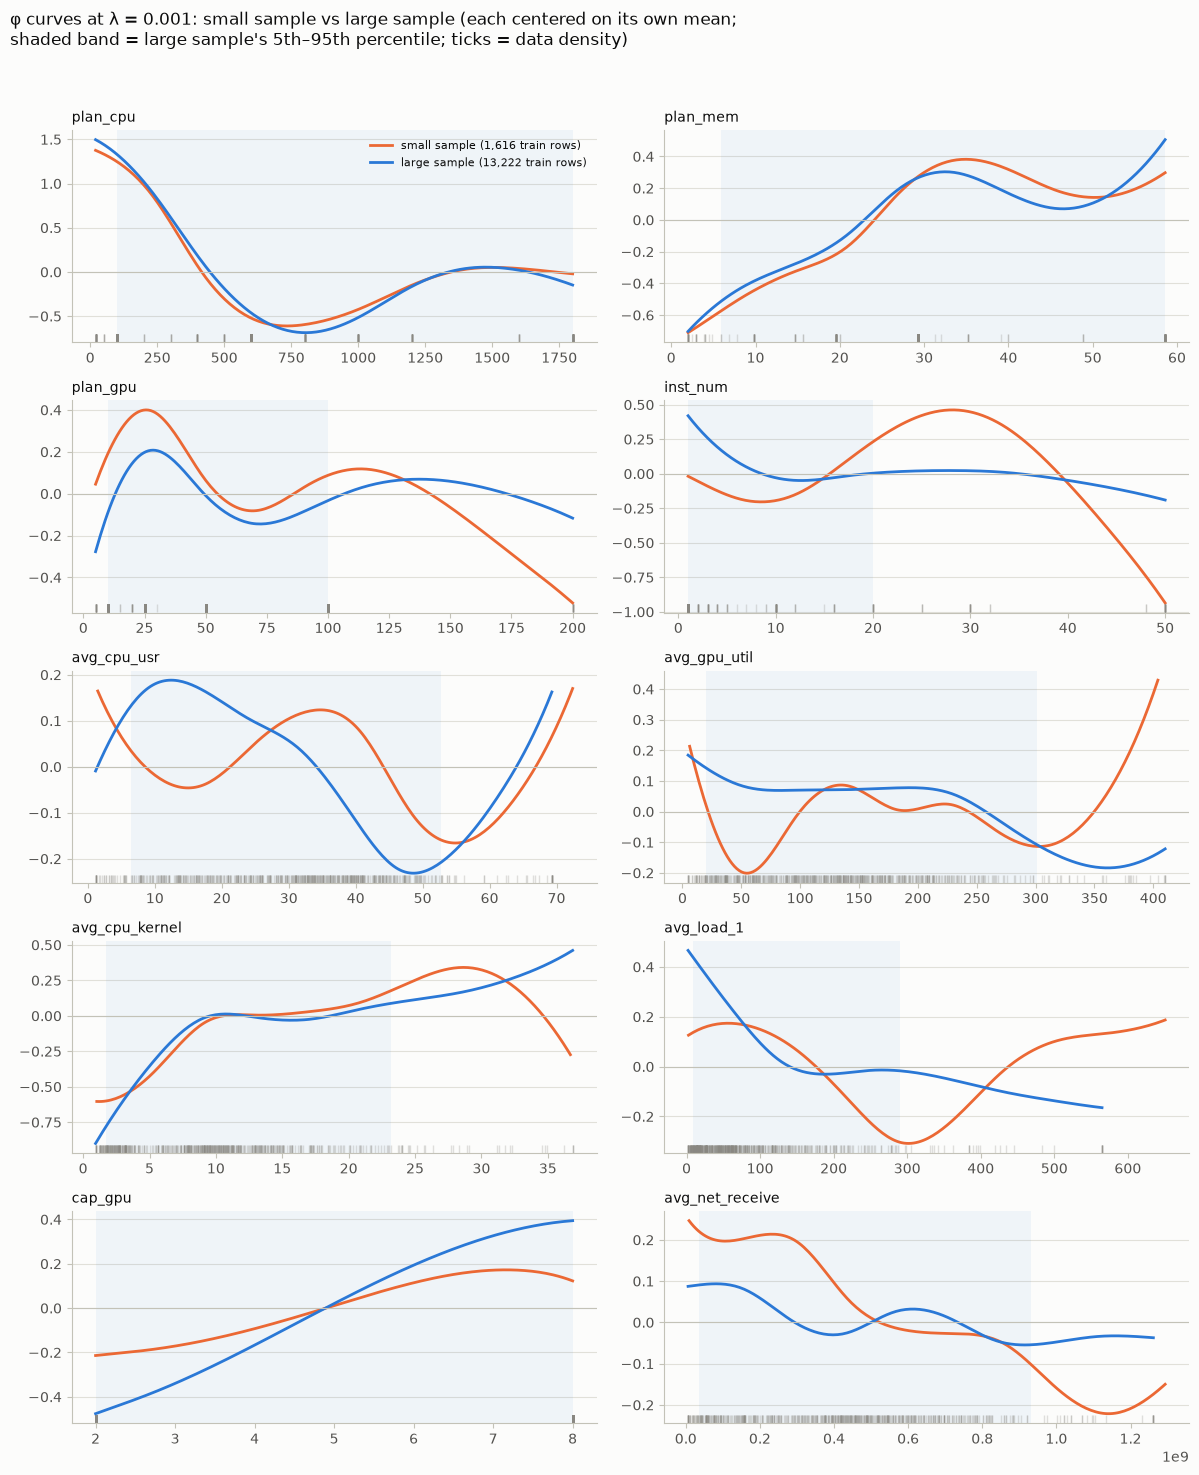

In [18]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15))
for ax, name in zip(axes.ravel(), FEATURE_NAMES):
    for label, color, style in ((("small", st.LAMBDA_SMOOTH), SMALL_COLOR, "-"),
                                (("large", st.LAMBDA_SMOOTH), LARGE_COLOR, "-")):
        model, result, X_ref = models[label]
        x_lo, x_hi = X_ref[name].min(), X_ref[name].max()
        grid, phi = st.phi_curve(model, name, result.feature_ranges, x_lo, x_hi, center="mean")
        ax.plot(grid, phi, style, color=color, lw=2,
                label=f"{label[0]} sample ({len(X_ref):,} train rows)")
    q_lo, q_hi = X_tr[name].quantile([0.05, 0.95])
    ax.axvspan(q_lo, q_hi, color=LARGE_COLOR, alpha=0.06, lw=0)
    ax.plot(X_tr[name].sample(min(600, len(X_tr)), random_state=0), np.full(min(600, len(X_tr)), 0.02), "|",
            color=MUTED, alpha=0.25, ms=6, transform=ax.get_xaxis_transform())
    ax.axhline(0, color=BASELINE, lw=0.8)
    ax.set_title(name, loc="left", fontsize=10)
    ax.grid(axis="y")
    ax.set_axisbelow(True)
axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle("φ curves at λ = 0.001: small sample vs large sample (each centered on its own mean;\n"
             "shaded band = large sample's 5th–95th percentile; ticks = data density)",
             x=0.005, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

In [19]:
ARTIFACT_FEATURES = ["plan_cpu", "plan_gpu", "inst_num", "avg_load_1"]
swing = {label: st.sparse_region_swing(model, result.feature_ranges, X_ref)
         for label, (model, result, X_ref) in models.items()}
names = {k: f"{k[0]}, λ={k[1]:g}" for k in swing}

ratio = pd.DataFrame({names[k]: v["tail / core"] for k, v in swing.items()})
tail = pd.DataFrame({names[k]: v["worst tail range"] for k, v in swing.items()})
core = pd.DataFrame({names[k]: v["core range (p5-p95)"] for k, v in swing.items()})

print("The artifact is a swing in the thin-data tails. Two views of the same four features:\n")
print("(a) ABSOLUTE worst-tail swing of φ, in log-odds — how far the curve actually moves out there:")
print(tail.loc[ARTIFACT_FEATURES].round(3).to_string())
print("\n(b) tail swing ÷ core swing — >1 means φ moves more in the tails than across the whole data body:")
print(ratio.loc[ARTIFACT_FEATURES].round(2).to_string())
print("\nfor reference, the dense-core range of the same curves:")
print(core.loc[ARTIFACT_FEATURES].round(3).to_string())

med = tail.loc[ARTIFACT_FEATURES].median()
print("\nMEDIAN absolute tail swing over the four flagged features (log-odds):")
for label in med.index:
    print(f"  {label:<18s} {med[label]:.3f}" +
          ("" if label.startswith("small, λ=0 ") or med[label] == med.iloc[0]
           else f"   ({med[label] / med.iloc[0] - 1:+.0%} vs the unpenalized small sample)"))

print("\nAll ten features, absolute worst-tail swing:")
print(tail.round(3).to_string())

The artifact is a swing in the thin-data tails. Two views of the same four features:

(a) ABSOLUTE worst-tail swing of φ, in log-odds — how far the curve actually moves out there:
            small, λ=0  small, λ=0.001  large, λ=0  large, λ=0.001
plan_cpu         0.004           0.128       0.112           0.167
plan_gpu         0.688           0.640       0.328           0.186
inst_num         1.599           1.397       0.808           0.213
avg_load_1       1.236           0.495       0.212           0.148

(b) tail swing ÷ core swing — >1 means φ moves more in the tails than across the whole data body:
            small, λ=0  small, λ=0.001  large, λ=0  large, λ=0.001
plan_cpu          0.00            0.07        0.06            0.08
plan_gpu          0.91            1.33        0.52            0.53
inst_num          2.88            3.21        1.32            0.46
avg_load_1        1.91            1.06        0.76            0.31

for reference, the dense-core range of the same cu

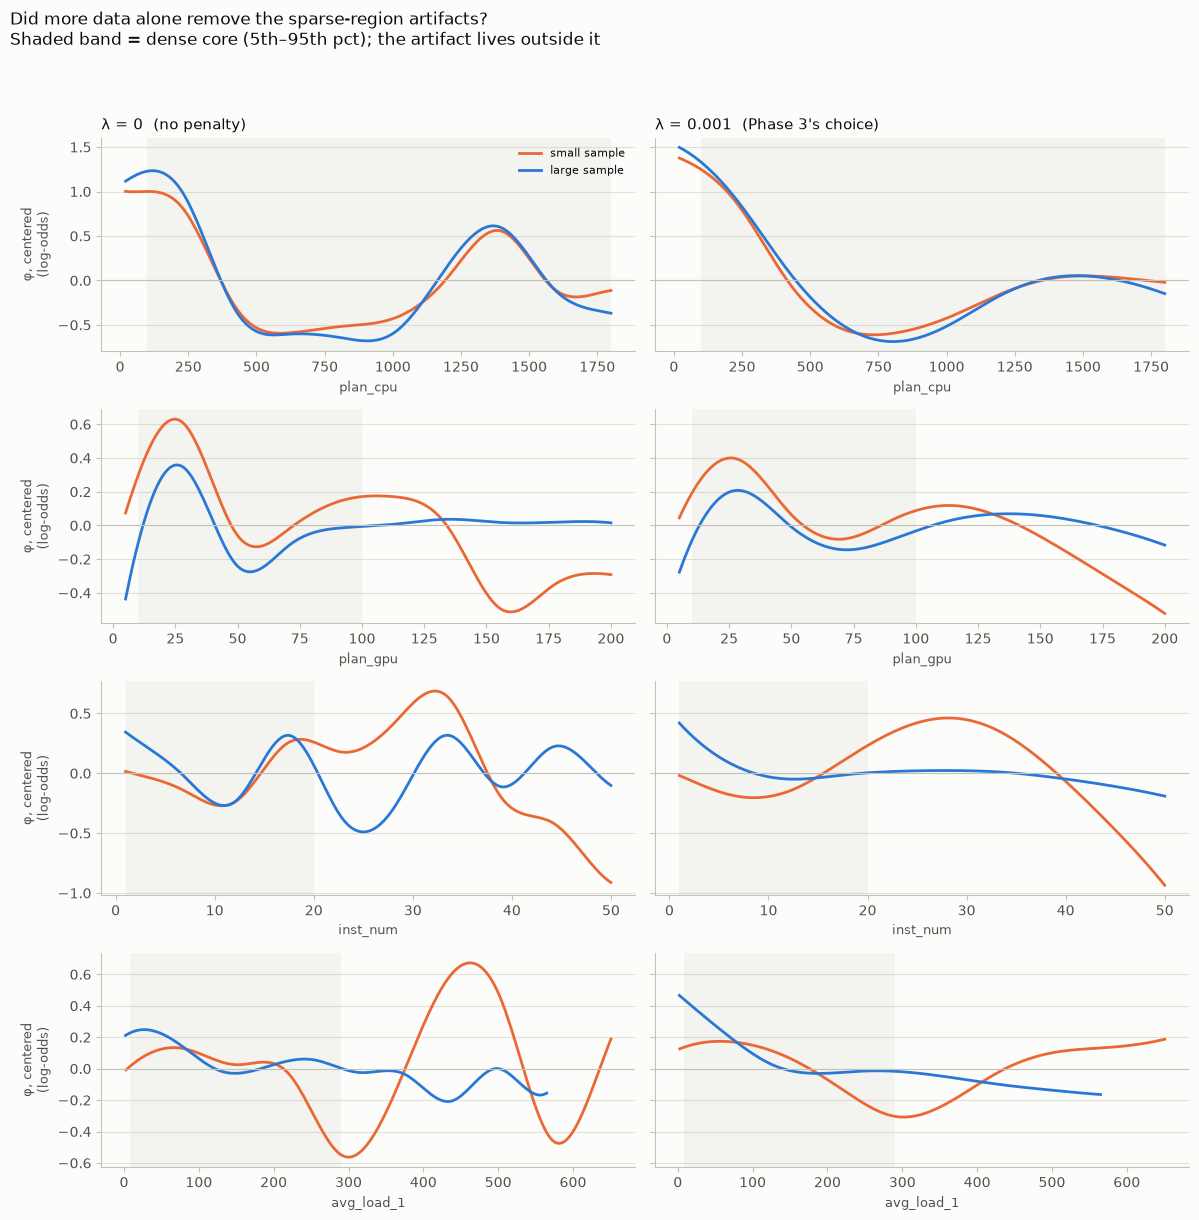

In [20]:
fig, axes = plt.subplots(len(ARTIFACT_FEATURES), 2, figsize=(12, 3.1 * len(ARTIFACT_FEATURES)), sharey="row")
for row, name in enumerate(ARTIFACT_FEATURES):
    for col, lam in enumerate([0.0, st.LAMBDA_SMOOTH]):
        ax = axes[row, col]
        for sample, color in (("small", SMALL_COLOR), ("large", LARGE_COLOR)):
            model, result, X_ref = models[(sample, lam)]
            grid, phi = st.phi_curve(model, name, result.feature_ranges,
                                     X_ref[name].min(), X_ref[name].max(), center="mean")
            ax.plot(grid, phi, color=color, lw=2, label=f"{sample} sample")
        q_lo, q_hi = X_tr[name].quantile([0.05, 0.95])
        ax.axvspan(q_lo, q_hi, color=BASELINE, alpha=0.15, lw=0)
        ax.axhline(0, color=BASELINE, lw=0.8)
        ax.grid(axis="y")
        ax.set_axisbelow(True)
        ax.set_xlabel(name, fontsize=9)
        if row == 0:
            ax.set_title(f"λ = {lam:g}" + ("  (no penalty)" if lam == 0 else "  (Phase 3's choice)"),
                         loc="left", fontsize=11)
    axes[row, 0].set_ylabel("φ, centered\n(log-odds)", fontsize=9)
axes[0, 0].legend(loc="best", fontsize=8)
fig.suptitle("Did more data alone remove the sparse-region artifacts?\n"
             "Shaded band = dense core (5th–95th pct); the artifact lives outside it",
             x=0.005, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

**Reading the artifact check. The answer is clear: more data alone removed most of the artifact, and removed more of it than the penalty alone did.**

Measured as the median absolute tail swing across the four flagged features:

| | small sample (1,616 train) | large sample (13,222 train) |
|---|---|---|
| **$\lambda = 0$** | **0.962** log-odds | **0.270** (−72%) |
| **$\lambda = 0.001$** | 0.568 (−41%) | **0.176** (−82%) |

- **Sample size did more work than regularization.** Going from 1,616 to 13,222 training rows with *no penalty at all* cut the median tail swing by 72%; keeping the small sample and adding Phase 3's penalty cut it by 41%. **Phase 3's smoothness penalty was substantially compensating for sample size.** That is the plain answer to the question this step was built to ask, and it is worth stating in the paper because it reframes what the penalty is for.
- **The penalty is still not redundant.** At scale it cuts the remaining tail swing by a further 35% (0.270 → 0.176) at negligible cost in AUC. It has simply moved from load-bearing to refining.
- **Per feature, the picture is consistent.** `inst_num` was the worst offender (1.599 unpenalized on the small sample) and improves most (0.808 with data alone, 0.213 with both). `avg_load_1` is nearly fixed by data alone (1.236 → 0.212). `plan_gpu` halves (0.688 → 0.328 → 0.186).
- **`plan_cpu` never had this artifact.** Its tail swing is 0.004 log-odds unpenalized on the small sample and rises slightly to 0.167 at scale — both negligible against its 1.6–2.0 log-odds core range. Whatever Phase 3 saw in `plan_cpu`, it was not a sparse-tail swing, and this ablation should not be read as vindicating that part of the original diagnosis.

**One caveat on comparability.** This 2×2 holds the initialization at the canonical seed 0 so that only sample size and $\lambda$ vary. Phase 3's published curves used seed 42, so the small-sample panels here are shape-comparable to Phase 3's but not pixel-identical to them.

## 7. The publication datasets

Three files, plus a data dictionary, written to `data/processed/publication/`.

**On identifiers.** This is Alibaba infrastructure telemetry, so there is no personal data and no MIMIC-style patient information anywhere in this pipeline. The residual concern is different and narrower: the feature matrix is **indexed by `(job_name, task_name)`**, which are Alibaba's own internal job and task strings. Those are proprietary identifiers rather than measurements, and nothing downstream needs them, so every export drops them and carries an anonymous row-number `task_id` instead. The audit at the end verifies this on the written files rather than on the in-memory frames.

In [21]:
import os
os.makedirs(PUBLICATION_DIR, exist_ok=True)

matrix, dropped_cols = st.strip_identifiers(X_large.assign(label=y_large))
matrix_path = f"{PUBLICATION_DIR}/kanvas_feature_matrix.csv"
matrix.to_csv(matrix_path, index=False)
print(f"kanvas_feature_matrix.csv   {matrix.shape[0]:,} rows x {matrix.shape[1]} columns")
print(f"  index (job_name, task_name) discarded; explicit identifier columns dropped: "
      f"{dropped_cols if dropped_cols else 'none present'}")
print(f"  columns: {', '.join(matrix.columns)}")

curves = st.curve_frame(kaam, kaam_result.feature_ranges, X_tr, num_points=200)
curves_path = f"{PUBLICATION_DIR}/kanvas_phi_curves.csv"
curves.to_csv(curves_path, index=False)
print(f"\nkanvas_phi_curves.csv       {len(curves):,} rows "
      f"({curves['feature_name'].nunique()} features x 200 grid points), long format")
print(f"  columns: {', '.join(curves.columns)}; from the canonical model, over each feature's 5th-95th percentile")

flat = table1.reset_index().rename(columns={"index": "model"})
flat = flat.merge(diffs.reset_index().rename(columns={"comparison": "model"}), on="model", how="outer")
bench_path = f"{PUBLICATION_DIR}/kanvas_benchmark_results.csv"
flat.to_csv(bench_path, index=False)
print(f"\nkanvas_benchmark_results.csv {len(flat)} rows x {flat.shape[1]} columns (Table 1 + the paired AUC intervals)")
print(f"  columns: {', '.join(map(str, flat.columns))}")

kanvas_feature_matrix.csv   18,890 rows x 12 columns
  index (job_name, task_name) discarded; explicit identifier columns dropped: none present
  columns: task_id, plan_cpu, plan_mem, plan_gpu, inst_num, avg_cpu_usr, avg_gpu_util, avg_cpu_kernel, avg_load_1, cap_gpu, avg_net_receive, label

kanvas_phi_curves.csv       2,000 rows (10 features x 200 grid points), long format
  columns: feature_name, x_value, phi_value; from the canonical model, over each feature's 5th-95th percentile

kanvas_benchmark_results.csv 6 rows x 14 columns (Table 1 + the paired AUC intervals)
  columns: model, accuracy, AUC, AUC 95% CI, precision, recall, F1, Brier, parameters, train seconds, AUC difference, 95% CI low, 95% CI high, CI includes 0


In [22]:
DICTIONARY = f'''# KANVAS publication data dictionary

Built from the Alibaba Cluster-Trace-GPU-2020 PAI trace (`pai_task_table`, `pai_instance_table`,
`pai_machine_metric`, `pai_machine_spec`). {len(matrix):,} tasks survive the full pipeline;
the failure rate is {y_large.mean():.2%}.

A task is joined to its first instance, and that instance's machine supplies the telemetry.
Machine features average **other jobs'** workers that ended on the assigned machine in the
**1 hour before** the task started, so no feature can see the task's own execution.

No personal data is involved. Alibaba's internal `job_name` / `task_name` identifiers are
deliberately not exported; `task_id` is an anonymous row number.

## kanvas_feature_matrix.csv

| column | source | meaning | units |
|---|---|---|---|
| `task_id` | (generated) | anonymous row number; carries no trace identifier | integer |
| `plan_cpu` | `pai_task_table.plan_cpu` | CPU the task requested | 100 = 1 core |
| `plan_mem` | `pai_task_table.plan_mem` | memory the task requested | GB |
| `plan_gpu` | `pai_task_table.plan_gpu` | GPU the task requested | 100 = 1 GPU |
| `inst_num` | `pai_task_table.inst_num` | instances the task requested | count |
| `avg_cpu_usr` | `pai_machine_metric.machine_cpu_usr` | mean user-space CPU on the assigned machine in the 1h lookback | percent |
| `avg_gpu_util` | `pai_machine_metric.machine_gpu` | mean GPU utilization on the assigned machine in the 1h lookback | percent (sums across GPUs, so >100 is normal) |
| `avg_cpu_kernel` | `pai_machine_metric.machine_cpu_kernel` | mean kernel-space CPU on the assigned machine in the 1h lookback | percent |
| `avg_load_1` | `pai_machine_metric.machine_load_1` | mean 1-minute load average on the assigned machine in the 1h lookback | load units |
| `cap_gpu` | `pai_machine_spec.cap_gpu` | GPUs physically installed on the assigned machine | count |
| `avg_net_receive` | `pai_machine_metric.machine_net_receive` | mean network receive rate on the assigned machine in the 1h lookback | bytes/s |
| `label` | `pai_task_table.status` | 1 = Failed, 0 = Terminated; Running/Waiting dropped as unresolved | binary |

All ten features are clipped to their 1st/99th percentile, and rows with any NaN are dropped,
both inside `build_kanvas_dataset`.

## kanvas_phi_curves.csv

The canonical KAAM model's learned per-feature curves, long format and directly plottable.

| column | meaning |
|---|---|
| `feature_name` | one of the ten features above |
| `x_value` | feature value in raw units, 200 points spanning that feature's 5th-95th training percentile |
| `phi_value` | that feature's additive contribution to the failure log-odds, centered on the curve's own mean |

KAAM's prediction is `sigmoid(bias + sum_i phi_i(x_i))`, so these curves *are* the model's
explanation exactly, not an approximation of it.

## kanvas_benchmark_results.csv

Table 1 in flat form: one row per model (KAAM, logistic regression, capacity-matched MLP) with
accuracy, AUC and its bootstrap interval, precision, recall, F1, Brier score, learnable parameter
count and training wall-clock seconds; plus one row per model pair carrying the paired-bootstrap
95% interval on the AUC difference (2,000 resamples of the test rows).

Canonical run: split `random_state={st.CANONICAL_SPLIT_STATE}`, initialization seed
{st.CANONICAL_INIT_SEED}, both fixed before any metric was computed.
'''

dict_path = f"{PUBLICATION_DIR}/data_dictionary.md"
with open(dict_path, "w", encoding="utf-8") as fh:
    fh.write(DICTIONARY)
print(f"wrote {dict_path} ({len(DICTIONARY):,} characters)")

wrote ../data/processed/publication/data_dictionary.md (3,310 characters)


In [23]:
audit = st.audit_exports([matrix_path, curves_path, bench_path])
print("Export audit - identifier columns are checked on the written files, not the in-memory frames:\n")
print(audit.to_string())
print(f"\nforbidden column list: {st.FORBIDDEN_COLUMNS}")
assert audit["clean"].all(), "an export carries an identifier column"
print("\nALL THREE EXPORTS CLEAN: no user, job_name, task_name, machine, worker_name or gpu_type column.")

print("\nSpot check - first 3 rows of each file as written to disk:")
for path in [matrix_path, curves_path, bench_path]:
    print(f"\n--- {os.path.basename(path)} ---")
    print(pd.read_csv(path).head(3).to_string(index=False))

Export audit - identifier columns are checked on the written files, not the in-memory frames:

                               rows  columns identifier columns   text columns  clean
file                                                                                 
kanvas_feature_matrix.csv     18890       12               none           none   True
kanvas_phi_curves.csv          2000        3               none           none   True
kanvas_benchmark_results.csv      6       14               none  CI includes 0   True

forbidden column list: ['user', 'job_name', 'task_name', 'machine', 'worker_name', 'inst_id', 'gpu_type']

ALL THREE EXPORTS CLEAN: no user, job_name, task_name, machine, worker_name or gpu_type column.

Spot check - first 3 rows of each file as written to disk:

--- kanvas_feature_matrix.csv ---
 task_id  plan_cpu  plan_mem  plan_gpu  inst_num  avg_cpu_usr  avg_gpu_util  avg_cpu_kernel  avg_load_1  cap_gpu  avg_net_receive  label
       0     600.0 29.296875      50.0 

## Summary

| Question | Answer |
|---|---|
| **Does the pipeline scale?** | Yes, on the first attempt. 40,000 sampled tasks → **18,890 clean rows** (47.2% yield vs 46.2% at 5,000 tasks), no doubling needed. The attrition pattern is nearly identical stage by stage. |
| **Was the small sample representative?** | Yes, and not marginally. Largest mean shift across ten features **0.03σ** (threshold 0.2); largest percentile-window shift **0.05 widths** (threshold 0.2); failure rates 0.47 points apart. No feature flagged. Phase 3's curves need no distributional caveat. |
| **Initialization variance (Experiment A)** | **Negligible.** Five seeds, test AUC std **0.0001**, total range 0.0002. The optimizer lands in the same place every time. |
| **Split variance (Experiment B)** | **Moderate, and 145× larger.** Five splits, test AUC std **0.0104**, range 0.0229 (0.7318–0.7547). Split dominates on every metric: AUC 145×, F1 114×, accuracy 47×. |
| **Which source dominates?** | The **split**, decisively. A single test AUC should be quoted with its split, not to three decimals. Even so, the whole ten-run spread is smaller than the ±0.047 interval Phase 4's 347-task bootstrap carried. |
| **Table 1 at scale** | KAAM **0.7520** AUC / 0.8095 acc / 0.5755 F1 / 0.1527 Brier / 151 params. MLP 0.7558 / 0.8151 / 0.5726 / 0.1535 / 149. LR 0.7346 / 0.7936 / 0.4961 / 0.1684 / 11. |
| **Is the interpretability cost real?** | **No — it is not measurable.** KAAM − MLP = −0.0038 [−0.0183, +0.0103], still includes zero with 8× the data. KAAM's Brier and F1 now marginally beat the MLP's. |
| **Is the gain over linear real?** | **Yes, now significant.** KAAM − LR = +0.0174 [+0.0041, +0.0302], excludes zero, where Phase 4 could not resolve it. The gap that is real is linear-vs-curved, not additive-vs-black-box. |
| **SHAP agreement at scale** | **Held.** ρ = 0.745, p = 0.0133 (Phase 4: 0.782, p = 0.0075). `plan_cpu` still rank 1/1 with the same ~28% share. The `cap_gpu` credit split persists; a new, larger disagreement appeared on **`plan_gpu`** (KAAM rank 8 vs SHAP rank 3), most plausibly an interaction an additive model cannot represent. |
| **Did more data alone remove the artifacts?** | **Mostly, yes — and more than the penalty did.** Median tail swing over the four flagged features: 0.962 (small, λ=0) → **0.270 with data alone (−72%)** vs 0.568 with the penalty alone (−41%), and 0.176 with both. Phase 3's penalty was substantially compensating for sample size; at scale it refines rather than rescues. `plan_cpu` never showed this artifact at all. |
| **Publication files** | Three CSVs + `data_dictionary.md` in `data/processed/publication/`, audited **on disk**: no `user`, `job_name`, `task_name`, `machine`, `worker_name` or `gpu_type` column in any of them. The `(job_name, task_name)` index is replaced by an anonymous `task_id`. |

### What the paper can now claim, and what it cannot

**Can claim.** On 18,890 tasks from a real production GPU cluster, an additive model whose every feature effect is a readable curve matches a capacity-matched neural network on ranking, calibration and F1, and significantly beats logistic regression. Its built-in explanation agrees with an independent post-hoc explanation of that network at ρ ≈ 0.75. The result is insensitive to initialization and its split-to-split variation is quantified, not assumed.

**Cannot claim.** That KAAM *beats* the MLP — the interval includes zero and the point estimate favors the MLP. That per-feature attribution is unique — it is not, among correlated features, and `plan_gpu` now shows a disagreement that additivity itself may explain. That the smoothness penalty is what makes the curves trustworthy — at this sample size, the data does most of that work.

### Open items

- **The 500-epoch cap binds at scale.** Every large-sample run used all 500 epochs with early stopping never firing, where the small sample stopped at 167. Patience and `max_epochs` are Phase 3 choices and were deliberately not re-tuned, so KAAM here is trained to a fixed budget rather than to convergence; its numbers are conservative. Re-deciding that budget is a legitimate next phase, on a fresh split.
- **`plan_gpu`'s new SHAP disagreement is unexplained.** Testing whether it is an interaction (e.g. with `plan_cpu` or `cap_gpu`) would either confirm a structural limit of the additive family or reveal something fixable.
- **Only KAAM was run multi-seed.** The MLP's and LR's own split variance is unmeasured, so Table 1's model ordering carries that unquantified.